In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_A_PERFECT.csv to dataset_A_PERFECT.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving dataset_B_SYNONYM.csv to dataset_B_SYNONYM.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving dataset_C_LOGIC_ERROR.csv to dataset_C_LOGIC_ERROR.csv



 Method 1- Rule based results 
Accuracy A: 75.00 %
Accuracy B: 10.00 %
Accuracy C: 20.00 %
-----------------------------------
False Alarm A: 25.00 %
False Alarm B: 90.00 %
Logic Error Recall C: 20.00 %
-----------------------------------
Saved: predictions_A_basic.csv
Saved: predictions_B_basic.csv
Saved: predictions_C_basic.csv


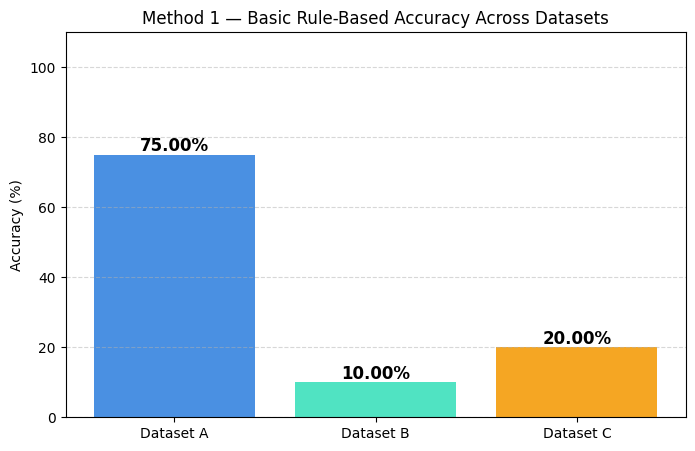

In [6]:
# METHOD 1 — BASIC RULE-BASED METHOD

import re
import string
import pandas as pd
from difflib import SequenceMatcher
import matplotlib.pyplot as plt

# Text cleaning

def clean_text(text):
    return text.lower().translate(str.maketrans("", "", string.punctuation)).strip()

# Term extraaction from requirement
def extract_terms_requirement(req):
    words = clean_text(req).split()
    return set([w for w in words if len(w) > 3])

# Term extraction from Plantuml

def extract_terms_plantuml(code):
    txt = clean_text(code)
    entities = re.findall(r'entity\s+(\w+)', txt)
    attrs = re.findall(r'(\w+)\s*[:]?', txt)
    return set([t for t in (entities + attrs) if len(t) > 3])

# Similarity

def similarity_score(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Balanaced Thresholds

TERM_THRESHOLD = 0.55
MATCH_RATIO_THRESHOLD = 0.45

# PREDICTION
#-ks 11/28 upladesd

def rule_based_predict(requirement, diagram):
    req_terms = extract_terms_requirement(requirement)
    dia_terms = extract_terms_plantuml(diagram)

    if not req_terms or not dia_terms:
        return "MISMATCH"

    matches = 0
    for r in req_terms:
        best = max(similarity_score(r, d) for d in dia_terms)
        if best >= TERM_THRESHOLD:
            matches += 1

    match_ratio = matches / len(req_terms)
    return "MATCH" if match_ratio >= MATCH_RATIO_THRESHOLD else "MISMATCH"


# evaluation metrics
#-nb/ch 1128 added

def evaluate_accuracy(path):
    df = pd.read_csv(path)
    correct = sum(rule_based_predict(r, p) == lbl
                  for r, p, lbl in zip(df["Requirement"], df["PlantUML"], df["Label"]))
    return (correct / len(df)) * 100

def false_alarm_rate(path):
    df = pd.read_csv(path)
    false_alarms = sum(rule_based_predict(r, p) == "MISMATCH"
                       for r, p in zip(df["Requirement"], df["PlantUML"]))
    return (false_alarms / len(df)) * 100

def logic_error_recall(path):
    df = pd.read_csv(path)
    true_detect = sum(rule_based_predict(r, p) == "MISMATCH"
                      for r, p in zip(df["Requirement"], df["PlantUML"]))
    return (true_detect / len(df)) * 100


# Graph output
#---Ming 11/28 added
def plot_accuracy_bar(acc_A, acc_B, acc_C):
    labels = ["Dataset A", "Dataset B", "Dataset C"]
    values = [acc_A, acc_B, acc_C]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=["#4a90e2", "#50e3c2", "#f5a623"])

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1,
                 f"{height:.2f}%", ha="center", fontsize=12, fontweight="bold")

    plt.ylim(0, 110)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.ylabel("Accuracy (%)")
    plt.title("Method 1 — Basic Rule-Based Accuracy Across Datasets")
    plt.show()

# Save Predictions

def generate_prediction_file(infile, outfile):
    df = pd.read_csv(infile)
    df["Prediction"] = [
        rule_based_predict(r, uml)
        for r, uml in zip(df["Requirement"], df["PlantUML"])
    ]
    df.to_csv(outfile, index=False)
    print("Saved:", outfile)

# Execution

A = "dataset_A_PERFECT.csv"
B = "dataset_B_SYNONYM.csv"
C = "dataset_C_LOGIC_ERROR.csv"

acc_A = evaluate_accuracy(A)
acc_B = evaluate_accuracy(B)
acc_C = evaluate_accuracy(C)

fa_A = false_alarm_rate(A)
fa_B = false_alarm_rate(B)
recall_C = logic_error_recall(C)

print("\n Method 1- Rule based results ")
print(f"Accuracy A: {acc_A:.2f} %")
print(f"Accuracy B: {acc_B:.2f} %")
print(f"Accuracy C: {acc_C:.2f} %")
print("-----------------------------------")
print(f"False Alarm A: {fa_A:.2f} %")
print(f"False Alarm B: {fa_B:.2f} %")
print(f"Logic Error Recall C: {recall_C:.2f} %")
print("-----------------------------------")
# Save prediction CSVs
generate_prediction_file(A, "predictions_A_basic.csv")
generate_prediction_file(B, "predictions_B_basic.csv")
generate_prediction_file(C, "predictions_C_basic.csv")

# Plot graph
plot_accuracy_bar(acc_A, acc_B, acc_C)


# New Section